<a href="https://colab.research.google.com/github/SalmanOkz/computer_vision/blob/main/complete_lab_manual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

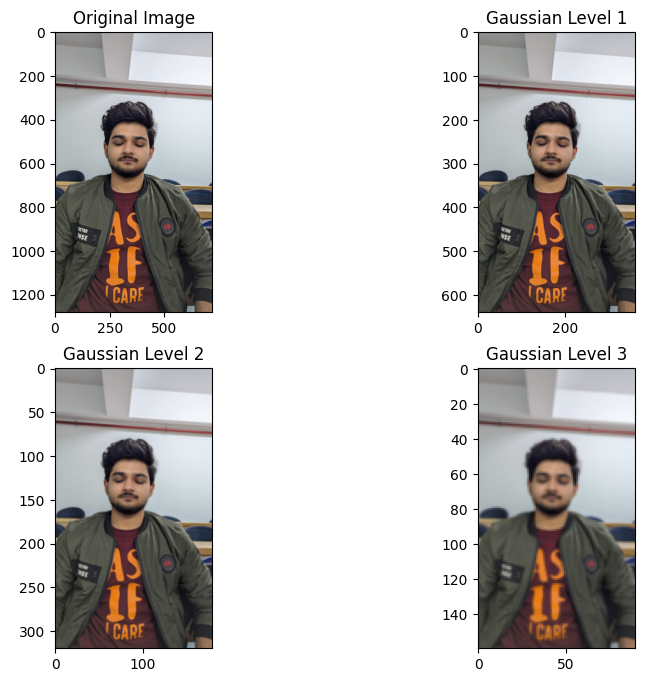

In [1]:
import cv2
from matplotlib import pyplot as plt

# Load original image
image = cv2.imread('/content/WhatsApp Image 2026-01-06 at 3.57.53 PM (1).jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Generate Gaussian Pyramid
gp1 = cv2.pyrDown(image)
gp2 = cv2.pyrDown(gp1)
gp3 = cv2.pyrDown(gp2)

# Display
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title('Original Image')

plt.subplot(2, 2, 2)
plt.imshow(gp1)
plt.title('Gaussian Level 1')

plt.subplot(2, 2, 3)
plt.imshow(gp2)
plt.title('Gaussian Level 2')

plt.subplot(2, 2, 4)
plt.imshow(gp3)
plt.title('Gaussian Level 3')

plt.show()


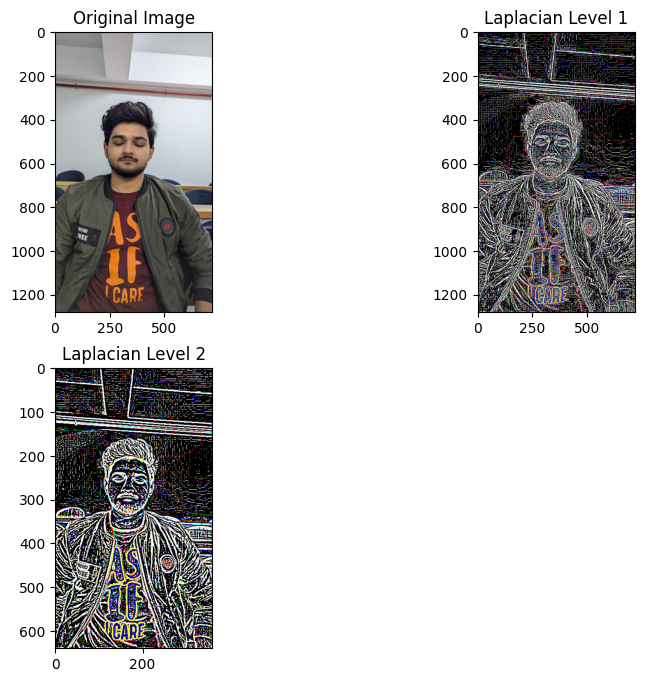

In [2]:
import cv2
from matplotlib import pyplot as plt

# Load and convert the image
image = cv2.imread('/content/WhatsApp Image 2026-01-06 at 3.57.53 PM (1).jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Gaussian Pyramid Levels
gp1 = cv2.pyrDown(image)
gp2 = cv2.pyrDown(gp1)

# Laplacian Levels
lp1 = image - cv2.pyrUp(gp1)[:image.shape[0], :image.shape[1]]  # Crop to match original image size
pyrUp_gp2 = cv2.pyrUp(gp2)
lp2 = gp1 - pyrUp_gp2[:gp1.shape[0], :gp1.shape[1]]  # Crop to match gp1 size

# Display Results
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title('Original Image')

plt.subplot(2, 2, 2)
plt.imshow(lp1)
plt.title('Laplacian Level 1')

plt.subplot(2, 2, 3)
plt.imshow(lp2)
plt.title('Laplacian Level 2')

plt.show()


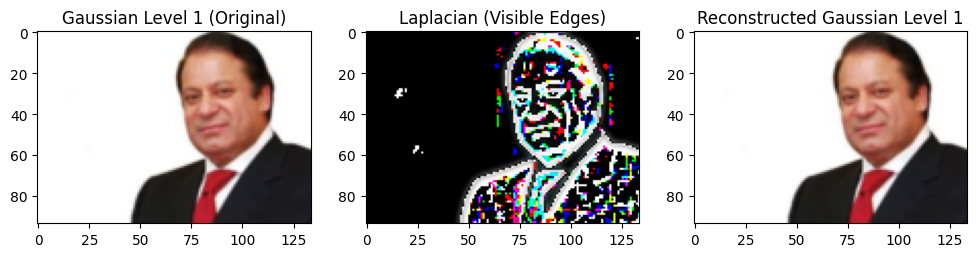

In [3]:
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('/content/theif.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Gaussian Pyramid
gp1 = cv2.pyrDown(image)  # First level of Gaussian pyramid
gp2 = cv2.pyrDown(gp1)   # Second level of Gaussian pyramid

# Laplacian Calculation
gp2_up = cv2.pyrUp(gp2)  # Upsample gp2 to match gp1's size
gp2_up = cv2.resize(gp2_up, (gp1.shape[1], gp1.shape[0]))  # Ensure dimensions match
lap = gp1 - gp2_up  # Laplacian = difference between gp1 and upsampled gp2

# Reconstruction
# Reconstruct gp1 by adding the Laplacian (lap) to the upsampled gp2 (gp2_up)
reconstructed = gp2_up + lap

# Display Results
plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1)
plt.imshow(gp1)
plt.title("Gaussian Level 1 (Original)")

plt.subplot(1, 3, 2)
plt.imshow(lap)
plt.title("Laplacian (Visible Edges)")

plt.subplot(1, 3, 3)
plt.imshow(reconstructed)
plt.title("Reconstructed Gaussian Level 1")

plt.show()


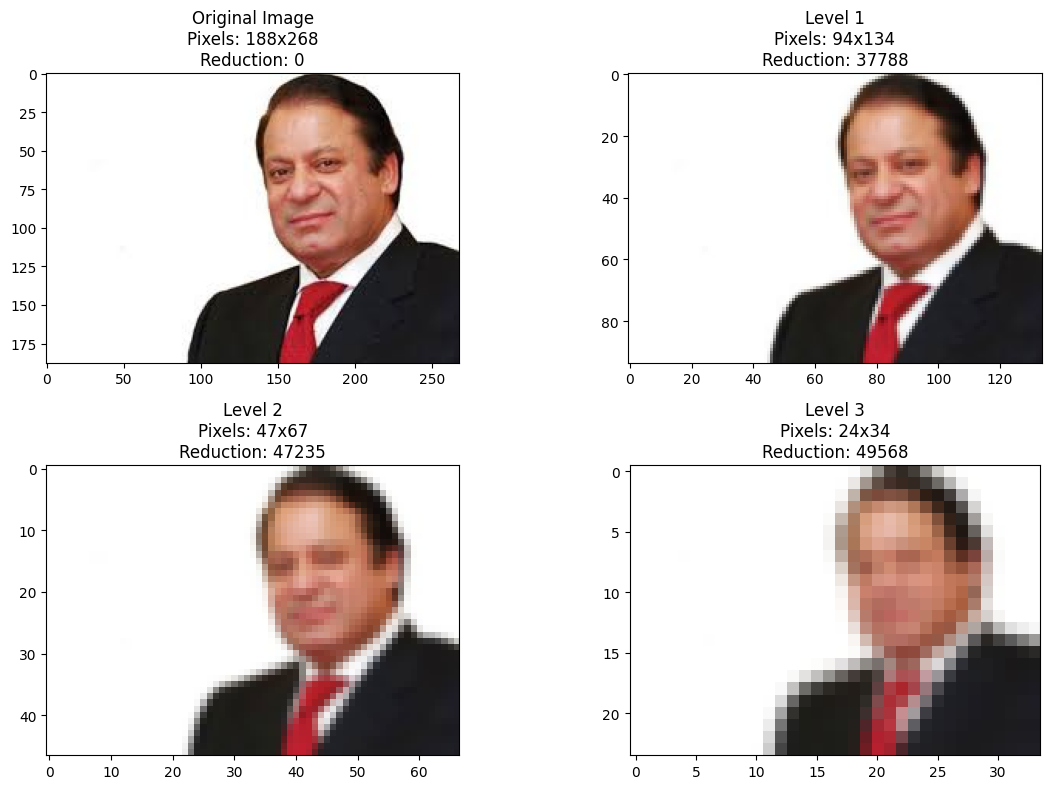

Pixel Reduction Summary:
Level 1: 37788 pixels reduced
Level 2: 47235 pixels reduced
Level 3: 49568 pixels reduced


In [4]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/theif.jpg'  # Replace with your image path
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

# Generate the four-level Gaussian Pyramid
gaussian_pyramid = [image]
for _ in range(3):  # 3 downsamples to get 4 levels total
    gaussian_pyramid.append(cv2.pyrDown(gaussian_pyramid[-1]))

# Calculate pixel reduction for each level
original_pixels = image.shape[0] * image.shape[1]
pixel_reductions = []
for level in gaussian_pyramid[1:]:
    current_pixels = level.shape[0] * level.shape[1]
    reduction = original_pixels - current_pixels
    pixel_reductions.append(reduction)

# Display the pyramid and pixel reductions
plt.figure(figsize=(12, 8))
titles = ['Original Image', 'Level 1', 'Level 2', 'Level 3']
for i, (img, title) in enumerate(zip(gaussian_pyramid, titles)):
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"{title}\nPixels: {img.shape[0]}x{img.shape[1]}\nReduction: {pixel_reductions[i-1] if i > 0 else 0}")

plt.tight_layout()
plt.show()

# Print pixel reduction summary
print("Pixel Reduction Summary:")
for i, reduction in enumerate(pixel_reductions, start=1):
    print(f"Level {i}: {reduction} pixels reduced")


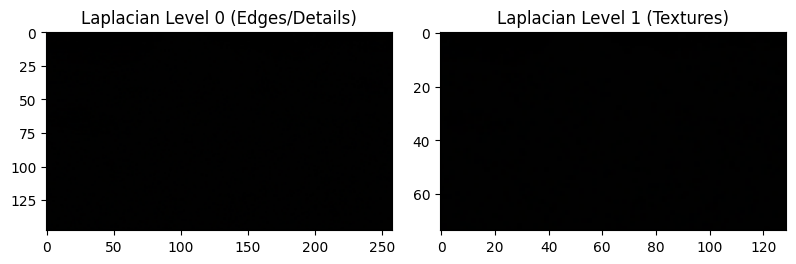

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/pahar.jpg'  # Replace with your image path
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Generate Gaussian Pyramid (3 levels)
gaussian_pyramid = [image]
for _ in range(2):  # 2 downsamples to get 3 levels total
    gaussian_pyramid.append(cv2.pyrDown(gaussian_pyramid[-1]))

# Generate Laplacian Pyramid
laplacian_pyramid = []
for i in range(len(gaussian_pyramid) - 1):
    # Upsample the smaller Gaussian level
    upsampled = cv2.pyrUp(gaussian_pyramid[i + 1])
    # Resize to match the current Gaussian level's dimensions
    upsampled = cv2.resize(upsampled, (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0]))
    # Laplacian level = current Gaussian level - upsampled smaller Gaussian level
    laplacian_level = gaussian_pyramid[i] - upsampled
    laplacian_pyramid.append(laplacian_level)

# The smallest Gaussian level is the last level
laplacian_pyramid.append(gaussian_pyramid[-1])  # Add the smallest Gaussian level as the last Laplacian level

# Display the Laplacian Pyramid
plt.figure(figsize=(12, 8))
titles = ['Laplacian Level 0 (Edges/Details)', 'Laplacian Level 1 (Textures)', 'Laplacian Level 2 (Coarse Details)']
for i, (lap_level, title) in enumerate(zip(laplacian_pyramid[:-1], titles)):
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(lap_level, 0, 1))  # Clip to visualize details
    plt.title(title)

plt.tight_layout()
plt.show()


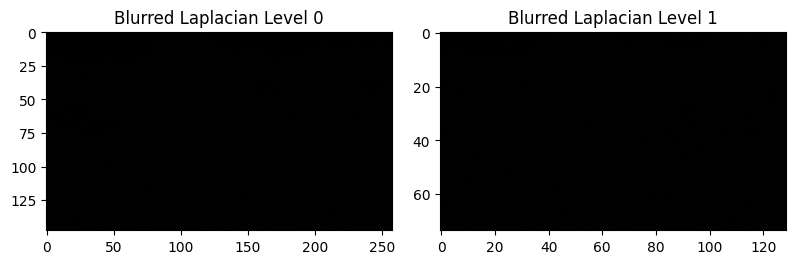

In [7]:
# Blur the smallest Gaussian level
blurred_gaussian = cv2.GaussianBlur(gaussian_pyramid[-1], (5, 5), 0)

# Reconstruct the Laplacian Pyramid with blurred smallest level
laplacian_pyramid_blurred = []
for i in range(len(gaussian_pyramid) - 1):
    upsampled = cv2.pyrUp(gaussian_pyramid[i + 1] if i < len(gaussian_pyramid) - 2 else blurred_gaussian)
    upsampled = cv2.resize(upsampled, (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0]))
    laplacian_level = gaussian_pyramid[i] - upsampled
    laplacian_pyramid_blurred.append(laplacian_level)

laplacian_pyramid_blurred.append(blurred_gaussian)  # Add blurred smallest level

# Display the blurred Laplacian Pyramid
plt.figure(figsize=(12, 8))
titles = ['Blurred Laplacian Level 0', 'Blurred Laplacian Level 1', 'Blurred Laplacian Level 2']
for i, (lap_level, title) in enumerate(zip(laplacian_pyramid_blurred[:-1], titles)):
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(lap_level, 0, 1))
    plt.title(title)

plt.tight_layout()
plt.show()


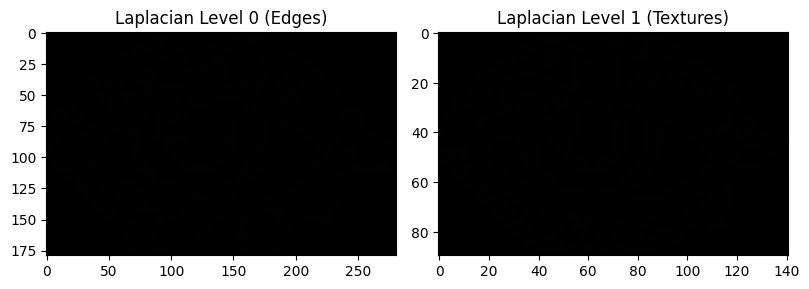

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load your image (replace with your image path)
image = cv2.imread('/content/download.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Generate Gaussian Pyramid (3 levels)
gaussian_pyramid = [image]
for _ in range(2):  # 2 downsamples to get 3 levels
    gaussian_pyramid.append(cv2.pyrDown(gaussian_pyramid[-1]))

# Generate Laplacian Pyramid
laplacian_pyramid = []
for i in range(len(gaussian_pyramid) - 1):
    # Upsample the smaller Gaussian level
    upsampled = cv2.pyrUp(gaussian_pyramid[i + 1])
    # Resize to match dimensions
    upsampled = cv2.resize(upsampled, (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0]))
    # Laplacian level = current Gaussian - upsampled smaller Gaussian
    laplacian_level = gaussian_pyramid[i] - upsampled
    laplacian_pyramid.append(laplacian_level)

# The smallest Gaussian level is the last level
laplacian_pyramid.append(gaussian_pyramid[-1])

# Display the Laplacian Pyramid
plt.figure(figsize=(12, 8))
titles = ['Laplacian Level 0 (Edges)', 'Laplacian Level 1 (Textures)', 'Laplacian Level 2 (Coarse Details)']
for i, (lap_level, title) in enumerate(zip(laplacian_pyramid[:-1], titles)):
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(lap_level, 0, 1))  # Clip for visualization
    plt.title(title)

plt.tight_layout()
plt.show()


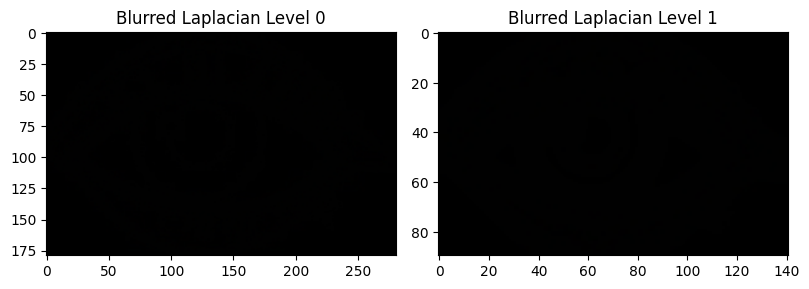

In [11]:
# Blur the smallest Gaussian level
blurred_gaussian = cv2.GaussianBlur(gaussian_pyramid[-1], (5, 5), 0)

# Reconstruct Laplacian Pyramid with blurred smallest level
laplacian_pyramid_blurred = []
for i in range(len(gaussian_pyramid) - 1):
    upsampled = cv2.pyrUp(gaussian_pyramid[i + 1] if i < len(gaussian_pyramid) - 2 else blurred_gaussian)
    upsampled = cv2.resize(upsampled, (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0]))
    laplacian_level = gaussian_pyramid[i] - upsampled
    laplacian_pyramid_blurred.append(laplacian_level)

laplacian_pyramid_blurred.append(blurred_gaussian)  # Add blurred smallest level

# Display the blurred Laplacian Pyramid
plt.figure(figsize=(12, 8))
titles = ['Blurred Laplacian Level 0', 'Blurred Laplacian Level 1', 'Blurred Laplacian Level 2']
for i, (lap_level, title) in enumerate(zip(laplacian_pyramid_blurred[:-1], titles)):
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(lap_level, 0, 1))
    plt.title(title)

plt.tight_layout()
plt.show()


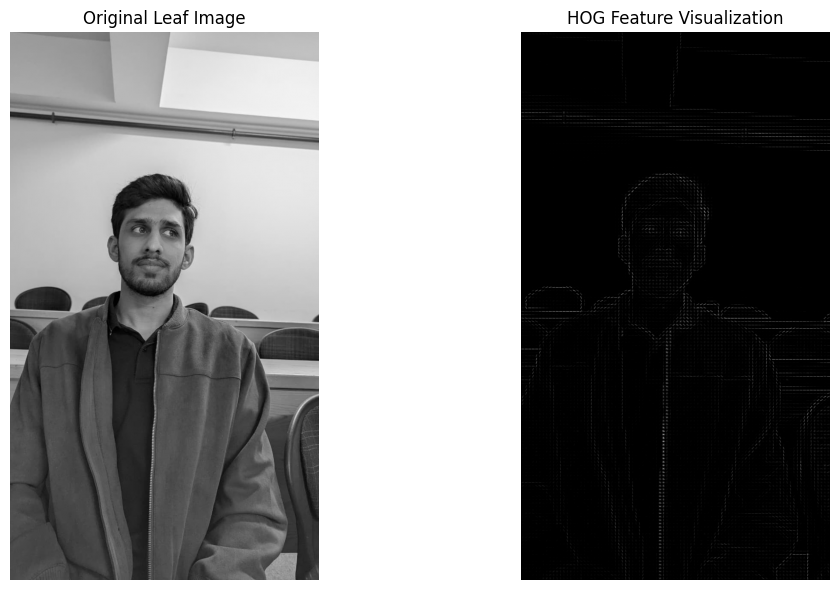

In [14]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from zipfile import ZipFile
import numpy as np
from io import BytesIO
from PIL import Image

# Path to your zip file
zip_path = '/content/dataset.zip'

# Open the zip file and read the first JPG image
with ZipFile(zip_path, 'r') as zip_ref:
    # List all files in the zip
    file_list = zip_ref.namelist()

    # Find the first JPG or JPEG image
    img_file = next((f for f in file_list if f.lower().endswith(('.jpg', '.jpeg'))), None)
    if img_file is None:
        raise ValueError("No JPG or JPEG image found in the zip file.")

    # Read the image data into memory
    with zip_ref.open(img_file) as file:
        img = Image.open(BytesIO(file.read())).convert('L')  # Convert to grayscale
        img_leaf = np.array(img)

# Compute HOG features
hog_features, hog_image = hog(
    img_leaf,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)

# Rescale HOG image for better visibility
hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(hog_image.min(), hog_image.max())
)

# Display the original image and HOG visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_leaf, cmap='gray')
plt.title("Original Leaf Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("HOG Feature Visualization")
plt.axis('off')

plt.tight_layout()
plt.show()